# BLIP Tutorial using HuggingFace

[View on Google Colab](https://colab.research.google.com/drive/1UsXI3Er7aWsL3pIDsFJ_FCJMlUnkdmTa?usp=sharing)

Contents Covered:
1. Loading BLIP Models using HuggingFace
2. Load Sample Image
3. Image Caption Generation
4. Visual Quesiton Answering
5. Image Text Matching
6. BLIP with HuggingFace Pipelines

### Import the necessary libraries

In [1]:
# !pip install torch transformers pillow matplotlib
# !pip install "numpy<2.0.0"

import torch
from transformers import (
    BlipProcessor, 
    BlipForConditionalGeneration,
    BlipForQuestionAnswering,
    BlipForImageTextRetrieval,
    pipeline
)
from PIL import Image
import requests
import numpy as np
from typing import List, Union, Tuple, Optional
import matplotlib.pyplot as plt

---

### Load the BLIP Models

In [2]:
def load_blip_model(
    model_name: str = "Salesforce/blip-image-captioning-base",
    task: str = "captioning"
) -> Tuple[Union[BlipForConditionalGeneration, BlipForQuestionAnswering, BlipForImageTextRetrieval], BlipProcessor]:
    """
    Load BLIP model and processor from Hugging Face.
    
    Args:
        model_name (str): Name of the BLIP model to load
        task (str): Task type - 'captioning', 'vqa', or 'retrieval'
        
    Returns:
        Tuple: Loaded model and processor
    """
    print(f"Loading BLIP model: {model_name}")
    print(f"Task: {task}")
    
    processor = BlipProcessor.from_pretrained(model_name)
    
    if task == "captioning":
        model = BlipForConditionalGeneration.from_pretrained(model_name)
    elif task == "vqa":
        model = BlipForQuestionAnswering.from_pretrained(model_name)
    elif task == "retrieval":
        model = BlipForImageTextRetrieval.from_pretrained(model_name)
    else:
        raise ValueError(f"Unsupported task: {task}")
    
    # Set to evaluation mode
    model.eval()
    
    print(f"Model loaded successfully!")
    print(f"Model config: {model.config}")
    
    return model, processor


# Execute: Load BLIP model for captioning
print("=" * 60)
print("LOADING BLIP MODEL FOR CAPTIONING")
print("=" * 60)
captioning_model, captioning_processor = load_blip_model(
    "Salesforce/blip-image-captioning-base", 
    "captioning"
)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


LOADING BLIP MODEL FOR CAPTIONING
Loading BLIP model: Salesforce/blip-image-captioning-base
Task: captioning


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Model loaded successfully!
Model config: BlipConfig {
  "architectures": [
    "BlipForConditionalGeneration"
  ],
  "dtype": "float32",
  "image_text_hidden_size": 256,
  "initializer_factor": 1.0,
  "initializer_range": 0.02,
  "label_smoothing": 0.0,
  "logit_scale_init_value": 2.6592,
  "model_type": "blip",
  "projection_dim": 512,
  "text_config": {
    "attention_probs_dropout_prob": 0.0,
    "dtype": "float32",
    "encoder_hidden_size": 768,
    "hidden_act": "gelu",
    "hidden_dropout_prob": 0.0,
    "hidden_size": 768,
    "initializer_factor": 1.0,
    "initializer_range": 0.02,
    "intermediate_size": 3072,
    "label_smoothing": 0.0,
    "layer_norm_eps": 1e-12,
    "max_position_embeddings": 512,
    "model_type": "blip_text_model",
    "num_attention_heads": 12,
    "num_hidden_layers": 12,
    "projection_dim": 768,
    "use_cache": true,
    "vocab_size": 30524
  },
  "transformers_version": "4.57.1",
  "vision_config": {
    "attention_dropout": 0.0,
    "dropout":

---

### Load Sample Image

In [3]:
def load_image_from_url(url: str) -> Image.Image:
    """
    Load an image from a URL.
    
    Args:
        url (str): URL of the image
        
    Returns:
        Image.Image: PIL Image object
    """
    try:
        response = requests.get(url, stream=True)
        response.raise_for_status()
        image = Image.open(response.raw)
        return image
    except Exception as e:
        print(f"Error loading image from URL: {e}")
        raise


# Execute: Load sample image
print("\n" + "=" * 60)
print("LOADING SAMPLE IMAGE")
print("=" * 60)
image_url = "http://images.cocodataset.org/val2017/000000039769.jpg"
sample_image = load_image_from_url(image_url)
print(f"Image loaded from: {image_url}")
print(f"Image size: {sample_image.size}")


LOADING SAMPLE IMAGE
Image loaded from: http://images.cocodataset.org/val2017/000000039769.jpg
Image size: (640, 480)


---

### Image Caption Generation

In [4]:
def generate_image_caption(
    image: Union[str, Image.Image],
    model: BlipForConditionalGeneration,
    processor: BlipProcessor,
    max_length: int = 50,
    num_beams: int = 5
) -> str:
    """
    Generate caption for an image using BLIP.
    
    Args:
        image (Union[str, Image.Image]): Image URL or PIL Image
        model (BlipForConditionalGeneration): BLIP model
        processor (BlipProcessor): BLIP processor
        max_length (int): Maximum caption length
        num_beams (int): Number of beams for beam search
        
    Returns:
        str: Generated caption
    """
    print("Generating image caption...")
    
    # Load image if URL provided
    if isinstance(image, str):
        image = load_image_from_url(image)
    
    # Process image
    inputs = processor(image, return_tensors="pt")
    
    # Generate caption
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_length=max_length,
            num_beams=num_beams,
            early_stopping=True
        )
    
    # Decode caption
    caption = processor.decode(out[0], skip_special_tokens=True)
    
    print(f"Generated Caption: '{caption}'")
    return caption


# Execute: Generate image caption
print("\n" + "=" * 60)
print("IMAGE CAPTIONING")
print("=" * 60)
caption = generate_image_caption(sample_image, captioning_model, captioning_processor)



IMAGE CAPTIONING
Generating image caption...
Generated Caption: 'two cats sleeping on a couch'


In [5]:
def conditional_image_captioning(
    image: Union[str, Image.Image],
    text_prompt: str,
    model: BlipForConditionalGeneration,
    processor: BlipProcessor,
    max_length: int = 50,
    num_beams: int = 5
) -> str:
    """
    Generate conditional caption for an image with text prompt using BLIP.
    
    Args:
        image (Union[str, Image.Image]): Image URL or PIL Image
        text_prompt (str): Text prompt to condition the caption
        model (BlipForConditionalGeneration): BLIP model
        processor (BlipProcessor): BLIP processor
        max_length (int): Maximum caption length
        num_beams (int): Number of beams for beam search
        
    Returns:
        str: Generated conditional caption
    """
    print(f"\nGenerating conditional caption with prompt: '{text_prompt}'")
    
    # Load image if URL provided
    if isinstance(image, str):
        image = load_image_from_url(image)
    
    # Process image and text
    inputs = processor(image, text_prompt, return_tensors="pt")
    
    # Generate caption
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_length=max_length,
            num_beams=num_beams,
            early_stopping=True
        )
    
    # Decode caption
    caption = processor.decode(out[0], skip_special_tokens=True)
    
    print(f"Generated Conditional Caption: '{caption}'")
    return caption


# Execute: Conditional image captioning
print("\n" + "=" * 60)
print("CONDITIONAL IMAGE CAPTIONING")
print("=" * 60)
text_prompts = [
    "a picture of",
    "this is",
    "I can see"
]

conditional_captions = []
for prompt in text_prompts:
    conditional_caption = conditional_image_captioning(
        sample_image, prompt, captioning_model, captioning_processor
    )
    conditional_captions.append(conditional_caption)



CONDITIONAL IMAGE CAPTIONING

Generating conditional caption with prompt: 'a picture of'
Generated Conditional Caption: 'a picture of two cats sleeping on a couch'

Generating conditional caption with prompt: 'this is'
Generated Conditional Caption: 'this is a cat'

Generating conditional caption with prompt: 'I can see'
Generated Conditional Caption: 'i can see two cats sleeping on the couch'


---

### Visual Question Answering

In [6]:
def load_blip_vqa_model(model_name: str = "Salesforce/blip-vqa-base") -> Tuple[BlipForQuestionAnswering, BlipProcessor]:
    """
    Load BLIP model specifically for Visual Question Answering.
    
    Args:
        model_name (str): Name of the BLIP VQA model
        
    Returns:
        Tuple: VQA model and processor
    """
    print(f"Loading BLIP VQA model: {model_name}")
    
    model = BlipForQuestionAnswering.from_pretrained(model_name)
    processor = BlipProcessor.from_pretrained(model_name)
    
    model.eval()
    print("VQA model loaded successfully!")
    
    return model, processor


# Execute: Load VQA model
print("\n" + "=" * 60)
print("LOADING BLIP VQA MODEL")
print("=" * 60)
vqa_model, vqa_processor = load_blip_vqa_model()


LOADING BLIP VQA MODEL
Loading BLIP VQA model: Salesforce/blip-vqa-base


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

VQA model loaded successfully!


In [7]:
def visual_question_answering(
    image: Union[str, Image.Image],
    question: str,
    model: BlipForQuestionAnswering,
    processor: BlipProcessor,
    max_length: int = 20
) -> str:
    """
    Answer questions about an image using BLIP VQA.
    
    Args:
        image (Union[str, Image.Image]): Image URL or PIL Image
        question (str): Question about the image
        model (BlipForQuestionAnswering): BLIP VQA model
        processor (BlipProcessor): BLIP processor
        max_length (int): Maximum answer length
        
    Returns:
        str: Generated answer
    """
    print(f"Answering question: '{question}'")
    
    # Load image if URL provided
    if isinstance(image, str):
        image = load_image_from_url(image)
    
    # Process image and question
    inputs = processor(image, question, return_tensors="pt")
    
    # Generate answer
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_length=max_length,
            num_beams=5,
            early_stopping=True
        )
    
    # Decode answer
    answer = processor.decode(out[0], skip_special_tokens=True)
    
    print(f"Answer: '{answer}'")
    return answer


# Execute: Visual Question Answering
print("\n" + "=" * 60)
print("VISUAL QUESTION ANSWERING")
print("=" * 60)
questions = [
    "What animals are in the image?",
    "How many cats are there?",
    "What are the cats doing?",
    "What color are the cats?",
    "Where are the cats located?"
]

answers = []
for question in questions:
    answer = visual_question_answering(sample_image, question, vqa_model, vqa_processor)
    answers.append(answer)



VISUAL QUESTION ANSWERING
Answering question: 'What animals are in the image?'
Answer: 'cats'
Answering question: 'How many cats are there?'
Answer: '2'
Answering question: 'What are the cats doing?'
Answer: 'sleeping'
Answering question: 'What color are the cats?'
Answer: 'brown and black'
Answering question: 'Where are the cats located?'
Answer: 'couch'


---

### Image Text Matching

In [8]:
def load_blip_retrieval_model(model_name: str = "Salesforce/blip-itm-base-coco") -> Tuple[BlipForImageTextRetrieval, BlipProcessor]:
    """
    Load BLIP model for Image-Text Matching/Retrieval.
    
    Args:
        model_name (str): Name of the BLIP ITM model
        
    Returns:
        Tuple: ITM model and processor
    """
    print(f"Loading BLIP ITM model: {model_name}")
    
    model = BlipForImageTextRetrieval.from_pretrained(model_name)
    processor = BlipProcessor.from_pretrained(model_name)
    
    model.eval()
    print("ITM model loaded successfully!")
    
    return model, processor


# Execute: Load ITM model
print("\n" + "=" * 60)
print("LOADING BLIP IMAGE-TEXT MATCHING MODEL")
print("=" * 60)
itm_model, itm_processor = load_blip_retrieval_model()


LOADING BLIP IMAGE-TEXT MATCHING MODEL
Loading BLIP ITM model: Salesforce/blip-itm-base-coco


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/895M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/895M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/456 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

ITM model loaded successfully!


In [9]:
def image_text_matching(
    image: Union[str, Image.Image],
    texts: List[str],
    model: BlipForImageTextRetrieval,
    processor: BlipProcessor
) -> List[float]:
    """
    Compute image-text matching scores using BLIP ITM.
    
    Args:
        image (Union[str, Image.Image]): Image URL or PIL Image
        texts (List[str]): List of text descriptions
        model (BlipForImageTextRetrieval): BLIP ITM model
        processor (BlipProcessor): BLIP processor
        
    Returns:
        List[float]: Matching scores for each text
    """
    print("Computing image-text matching scores...")
    
    # Load image if URL provided
    if isinstance(image, str):
        image = load_image_from_url(image)
    
    scores = []
    
    for text in texts:
        # Process image and text
        inputs = processor(image, text, return_tensors="pt")
        
        # Get matching score
        with torch.no_grad():
            outputs = model(**inputs)
            # ITM score (higher means better match)
            itm_score = torch.nn.functional.softmax(outputs.itm_score, dim=1)
            # Get the probability of match (index 1)
            match_prob = itm_score[0][1].item()
            scores.append(match_prob)
    
    print("Image-Text Matching Scores:")
    for i, (text, score) in enumerate(zip(texts, scores)):
        print(f"  '{text}': {score:.4f}")
    
    return scores


# Execute: Image-text matching
print("\n" + "=" * 60)
print("IMAGE-TEXT MATCHING")
print("=" * 60)
text_descriptions = [
    "two cats lying on a couch",
    "dogs playing in a park",
    "a car driving on a road", 
    "cats sleeping together",
    "animals resting indoors",
    "people walking on the street"
]
matching_scores = image_text_matching(sample_image, text_descriptions, itm_model, itm_processor)



IMAGE-TEXT MATCHING
Computing image-text matching scores...
Image-Text Matching Scores:
  'two cats lying on a couch': 0.9255
  'dogs playing in a park': 0.0000
  'a car driving on a road': 0.0000
  'cats sleeping together': 0.8856
  'animals resting indoors': 0.0680
  'people walking on the street': 0.0000


---

### BLIP with HuggingFace Pipelines

In [10]:
def blip_pipeline_demo(image: Union[str, Image.Image]):
    """
    Demonstrate BLIP using Hugging Face pipelines.
    
    Args:
        image (Union[str, Image.Image]): Image to process
    """
    print("Using BLIP with Hugging Face Pipelines...")
    
    # Image captioning pipeline
    print("\n1. Image Captioning Pipeline:")
    captioner = pipeline("image-to-text", model="Salesforce/blip-image-captioning-base")
    caption_result = captioner(image)
    print(f"Pipeline Caption: {caption_result[0]['generated_text']}")
    
    # Visual Question Answering pipeline
    print("\n2. Visual Question Answering Pipeline:")
    vqa_pipeline = pipeline("visual-question-answering", model="Salesforce/blip-vqa-base")
    
    sample_questions = [
        "What animals are shown?",
        "How many animals are there?",
        "What are they doing?"
    ]
    
    for question in sample_questions:
        result = vqa_pipeline(image=image, question=question)
        # VQA pipeline returns a list, so we need to access the first element
        if isinstance(result, list):
            result = result[0]
        print(f"Q: {question}")
        # Check if score is available, otherwise just show the answer
        if 'score' in result:
            print(f"A: {result['answer']} (score: {result['score']:.4f})")
        else:
            print(f"A: {result['answer']}")
            print(f"Available keys in result: {list(result.keys())}")


# Execute: Pipeline demo
print("\n" + "=" * 60)
print("BLIP PIPELINE DEMONSTRATION")
print("=" * 60)
blip_pipeline_demo(sample_image)



BLIP PIPELINE DEMONSTRATION
Using BLIP with Hugging Face Pipelines...

1. Image Captioning Pipeline:


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cpu


Pipeline Caption: two cats sleeping on a couch

2. Visual Question Answering Pipeline:


Device set to use cpu


Q: What animals are shown?
A: cats
Available keys in result: ['answer']
Q: How many animals are there?
A: 2
Available keys in result: ['answer']
Q: What are they doing?
A: sleeping
Available keys in result: ['answer']


---

### Results Visualizations


VISUALIZATION


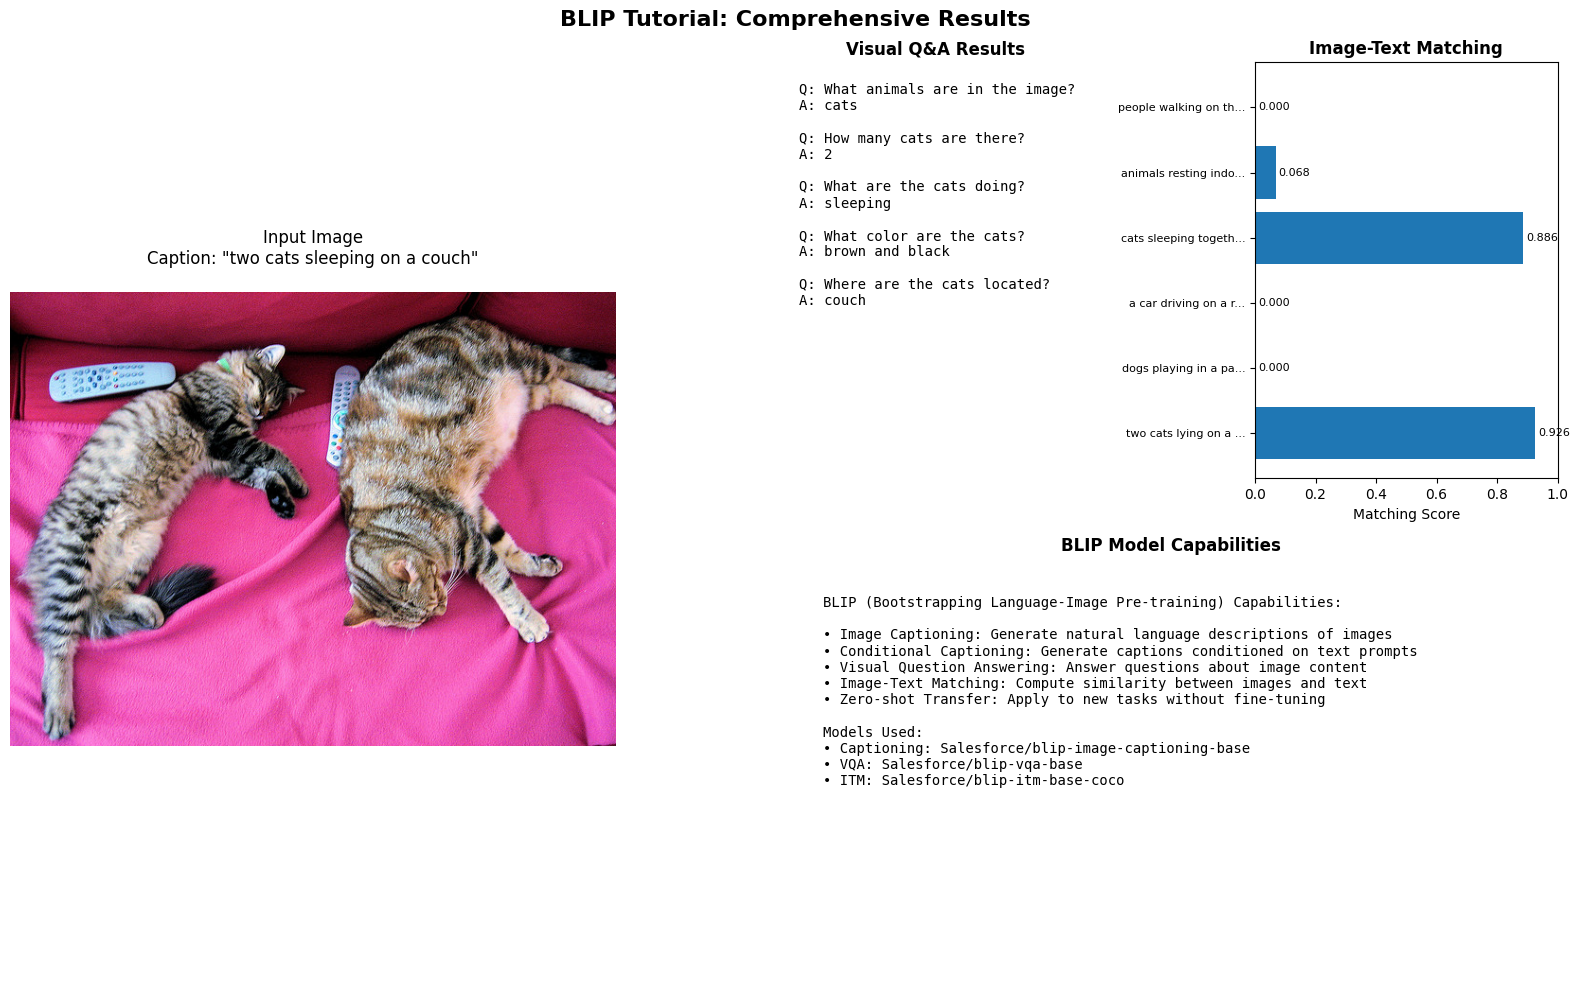


BLIP TUTORIAL COMPLETED!

Key BLIP capabilities demonstrated:
• Image Captioning (unconditional and conditional)
• Visual Question Answering
• Image-Text Matching/Retrieval
• Pipeline-based inference
• Comprehensive visualization


In [11]:
def visualize_blip_results(
    image: Image.Image,
    caption: str,
    vqa_pairs: List[Tuple[str, str]],
    itm_scores: List[Tuple[str, float]],
    title: str = "BLIP Model Results"
):
    """
    Visualize BLIP results with image, caption, VQA, and ITM scores.
    
    Args:
        image (Image.Image): Input image
        caption (str): Generated caption
        vqa_pairs (List[Tuple[str, str]]): Question-answer pairs
        itm_scores (List[Tuple[str, float]]): Text descriptions and matching scores
        title (str): Plot title
    """
    fig = plt.figure(figsize=(16, 10))
    
    # Create grid layout
    gs = fig.add_gridspec(2, 3, height_ratios=[1, 1], width_ratios=[2, 1, 1])
    
    # Display image
    ax1 = fig.add_subplot(gs[:, 0])
    ax1.imshow(image)
    ax1.axis('off')
    ax1.set_title(f'Input Image\nCaption: "{caption}"', fontsize=12, pad=20)
    
    # Display VQA results
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.axis('off')
    ax2.set_title('Visual Q&A Results', fontsize=12, fontweight='bold')
    
    vqa_text = ""
    for i, (q, a) in enumerate(vqa_pairs[:5]):  # Show top 5
        vqa_text += f"Q: {q}\nA: {a}\n\n"
    
    ax2.text(0.05, 0.95, vqa_text, transform=ax2.transAxes, fontsize=10,
             verticalalignment='top', fontfamily='monospace')
    
    # Display ITM scores
    ax3 = fig.add_subplot(gs[0, 2])
    texts, scores = zip(*itm_scores)
    y_pos = np.arange(len(texts))
    bars = ax3.barh(y_pos, scores)
    ax3.set_yticks(y_pos)
    ax3.set_yticklabels([t[:20] + '...' if len(t) > 20 else t for t in texts], fontsize=8)
    ax3.set_xlabel('Matching Score')
    ax3.set_title('Image-Text Matching', fontsize=12, fontweight='bold')
    ax3.set_xlim(0, 1)
    
    # Add value labels on bars
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax3.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{width:.3f}', ha='left', va='center', fontsize=8)
    
    # Add model comparison info
    ax4 = fig.add_subplot(gs[1, 1:])
    ax4.axis('off')
    ax4.set_title('BLIP Model Capabilities', fontsize=12, fontweight='bold')
    
    capabilities_text = """
BLIP (Bootstrapping Language-Image Pre-training) Capabilities:

• Image Captioning: Generate natural language descriptions of images
• Conditional Captioning: Generate captions conditioned on text prompts  
• Visual Question Answering: Answer questions about image content
• Image-Text Matching: Compute similarity between images and text
• Zero-shot Transfer: Apply to new tasks without fine-tuning

Models Used:
• Captioning: Salesforce/blip-image-captioning-base
• VQA: Salesforce/blip-vqa-base  
• ITM: Salesforce/blip-itm-base-coco
    """
    
    ax4.text(0.05, 0.95, capabilities_text, transform=ax4.transAxes, fontsize=10,
             verticalalignment='top', fontfamily='monospace')
    
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Execute: Visualization
print("\n" + "=" * 60)
print("VISUALIZATION")
print("=" * 60)

# Prepare data for visualization
vqa_pairs = list(zip(questions, answers))
itm_pairs = list(zip(text_descriptions, matching_scores))

visualize_blip_results(
    sample_image, 
    caption, 
    vqa_pairs, 
    itm_pairs,
    "BLIP Tutorial: Comprehensive Results"
)

print("\n" + "=" * 60)
print("BLIP TUTORIAL COMPLETED!")
print("=" * 60)
print("\nKey BLIP capabilities demonstrated:")
print("• Image Captioning (unconditional and conditional)")
print("• Visual Question Answering")
print("• Image-Text Matching/Retrieval")
print("• Pipeline-based inference")
print("• Comprehensive visualization")


---